# Exploratory Data Analysis
Objective: visually explore how middle east conflicts drive india's fuel and gas prices

In [6]:

#* import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

In [7]:

#^ plotting style
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight']= 'bold'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('tab10')

In [8]:

#~ load data
df = pd.read_csv('C:/Users/anasq/OneDrive/Desktop/PetroAnalyst/Dataset/ML_Ready_Data/EDA_data.csv', parse_dates=['date'])

df = df.sort_values('date').reset_index(drop=True)

#todo import dependency dataset
imports = pd.read_csv('C:/Users/anasq/OneDrive/Desktop/PetroAnalyst/Dataset/india_crude_import.csv')
# Filter to 2010 onwards
imports = imports[imports['year'] >= '2010-11'].reset_index(drop=True)

print('Master dataset shape:', df.shape)
print('Date range:', df['date'].min().strftime('%Y-%m'), '→', df['date'].max().strftime('%Y-%m'))
print('\nColumns:', list(df.columns))
print('\nNull values:', df.isnull().sum().sum())

Master dataset shape: (189, 50)
Date range: 2010-07 → 2026-03

Columns: ['date', 'brent_price', 'wti_price', 'usd_rate', 'GPR', 'avg_lpg_price', 'avg_petrol', 'avg_diesel', 'brent_lag1', 'brent_lag3', 'brent_lag6', 'wti_lag1', 'wti_lag3', 'gpr_lag1', 'gpr_lag3', 'usd_rate_lag1', 'usd_rate_lag3', 'lpg_price_lag1', 'lpg_price_lag3', 'petrol_price_lag1', 'petrol_price_lag3', 'diesel_price_lag1', 'diesel_price_lag3', 'brent_roll3', 'gpr_roll3', 'inr_roll3', 'brent_roll6', 'gpr_roll6', 'brent_pct_change', 'wti_pct_change', 'gpr_pct_change', 'inr_pct_change', 'lpg_pct_change', 'petrol_pct_change', 'diesel_pct_change', 'conflict_event', 'risk_level', 'crude_inr_impact', 'conflict_crude_index', 'brent_wti_spread', 'inr_gpr_stress', 'crude_inr_normalized', 'lpg_momentum', 'conflict_intensity', 'gpr_outlier', 'brent_outlier', 'lpg_price_outlier', 'petrol_price_outlier', 'diesel_price_outlier', 'usd_rate_outlier']

Null values: 0


# Statistical overview of data

In [9]:

#& DATASET OVERVIEW 

core_cols = ['brent_price', 'wti_price', 'usd_rate', 'GPR', 'avg_lpg_price', 'avg_petrol', 'avg_diesel']
print('=== DESCRIPTIVE STATISTICS ===')
print(df[core_cols].describe().round(2))

print('\n=== RISK LEVEL DISTRIBUTION ===')
risk_map = {0:'Low', 1:'Medium', 2:'High', 3:'Critical'}
print(df['risk_level'].map(risk_map).value_counts())

print('\n=== CONFLICT MONTHS ===')
print('Total conflict months flagged:', df['conflict_event'].sum())
print(df[df['conflict_event']==1][['date','GPR','brent_price','avg_lpg_price']].to_string())

=== DESCRIPTIVE STATISTICS ===
       brent_price  wti_price  usd_rate     GPR  avg_lpg_price  avg_petrol  \
count       189.00     189.00    189.00  189.00         189.00      189.00   
mean         77.61      71.41     68.59  105.67         788.29       82.30   
std          24.34      20.94     12.08   35.92         177.43       16.27   
min          18.38      16.55     44.30   58.42         378.40       54.45   
25%          59.71      54.66     61.81   81.66         648.40       69.26   
50%          74.84      70.98     68.05   96.80         811.70       77.63   
75%         101.61      88.58     76.19  119.84         911.70      100.34   
max         125.45     114.84     92.82  318.95        1244.40      110.26   

       avg_diesel  
count      189.00  
mean        67.53  
std         18.26  
min         39.88  
25%         50.84  
50%         64.09  
75%         88.04  
max         97.04  

=== RISK LEVEL DISTRIBUTION ===
risk_level
Low         101
Medium       74
High      

# Individual feature trends (2010-2026)

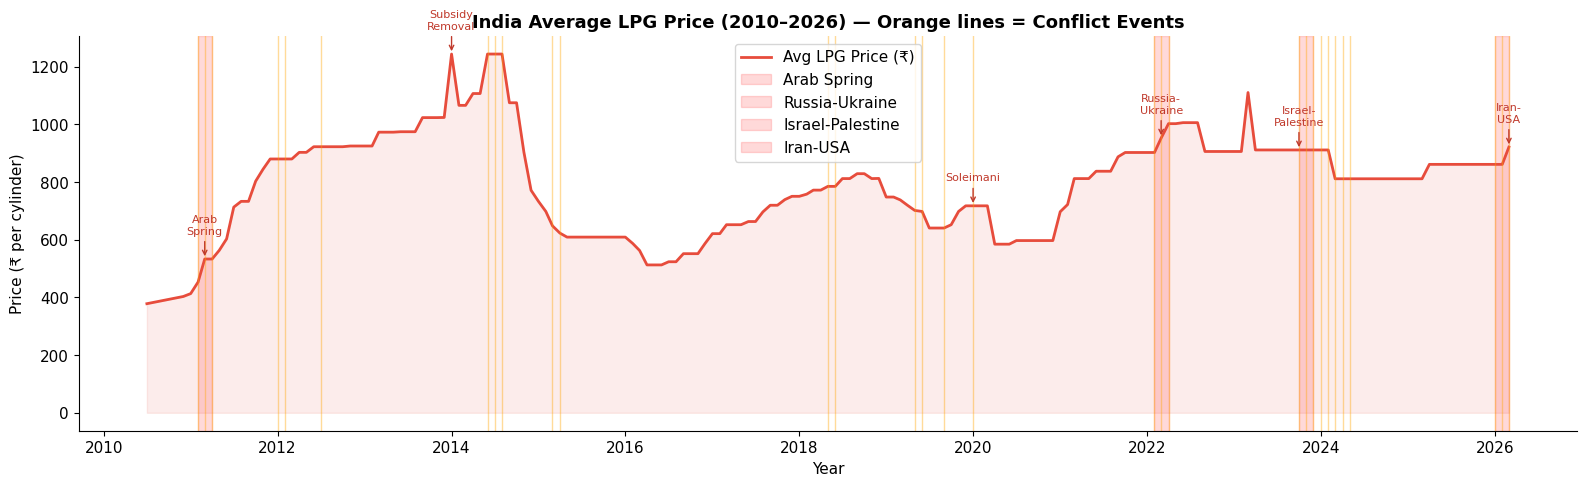

Saved: eda_01_lpg_trend.png


In [10]:

#^ LPG price trend

conflict_months = df[df['conflict_event'] == 1]['date']

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df['date'], df['avg_lpg_price'], color='#e74c3c', linewidth=2, label='Avg LPG Price (₹)')
ax.fill_between(df['date'], df['avg_lpg_price'], alpha=0.1, color='#e74c3c')

#todo Mark conflict months
for d in conflict_months:
    ax.axvline(x=d, color='orange', alpha=0.4, linewidth=1)

#? key events
events = {
    '2011-03-01': 'Arab\nSpring',
    '2014-01-01': 'Subsidy\nRemoval',
    '2020-01-01': 'Soleimani',
    '2022-03-01': 'Russia-\nUkraine',
    '2023-10-01': 'Israel-\nPalestine',
    '2026-03-01': 'Iran-\nUSA'
}

for date_str, label in events.items():
    try:
        d = pd.to_datetime(date_str)
        y = df[df['date'] == d]['avg_lpg_price'].values
        if len(y) > 0:
            ax.annotate(label, xy=(d, y[0]), xytext=(0, 18),
                        textcoords='offset points', ha='center',
                        fontsize=8, color='#c0392b',
                        arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1))
    except: pass

#! Shade conflict periods
conflict_periods = [
    ('2011-02-01', '2011-04-01', 'Arab Spring'),
    ('2022-02-01', '2022-04-01', 'Russia-Ukraine'),
    ('2023-10-01', '2023-12-01', 'Israel-Palestine'),
    ('2026-01-01', '2026-03-01', 'Iran-USA'),
]
for start, end, label in conflict_periods:
    ax.axvspan(pd.to_datetime(start), pd.to_datetime(end), alpha=0.15, color='red', label=label)

ax.set_title('India Average LPG Price (2010–2026) — Orange lines = Conflict Events')
ax.set_ylabel('Price (₹ per cylinder)')
ax.set_xlabel('Year')
ax.legend()
plt.tight_layout()
plt.savefig('eda_01_lpg_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_01_lpg_trend.png')

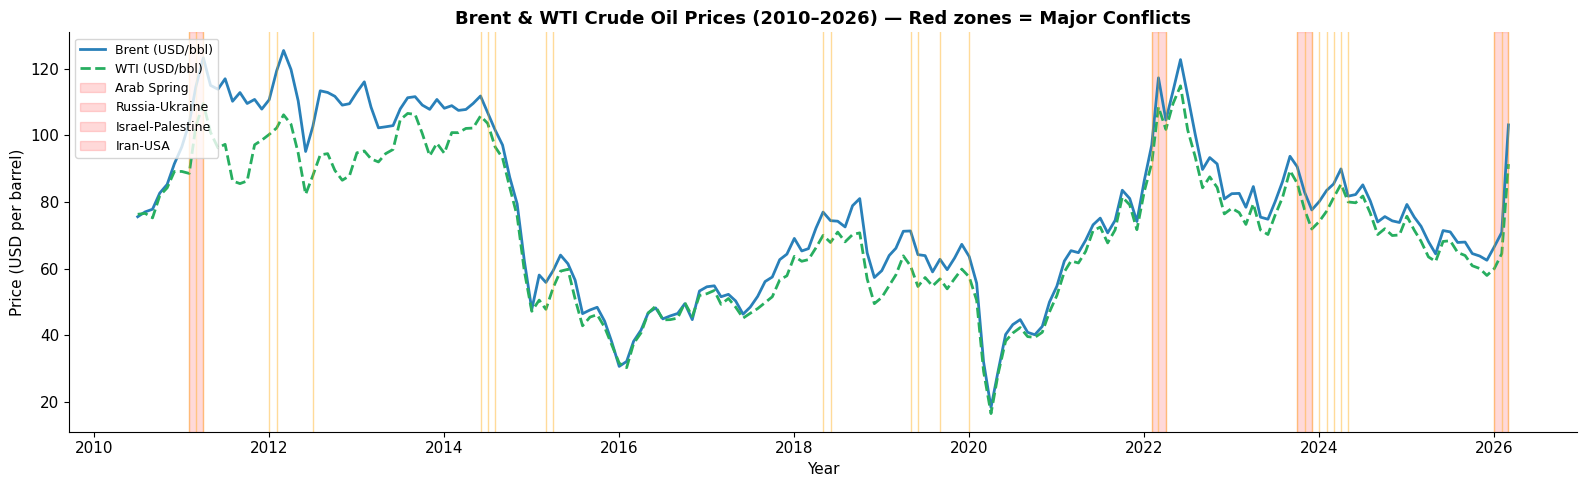

Saved: eda_02_crude_trend.png


In [11]:

#* Brent & WTI Crude Oil Trend
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df['date'], df['brent_price'], color='#2980b9', linewidth=2, label='Brent (USD/bbl)')
ax.plot(df['date'], df['wti_price'],   color='#27ae60', linewidth=2, label='WTI (USD/bbl)', linestyle='--')

for d in conflict_months:
    ax.axvline(x=d, color='orange', alpha=0.4, linewidth=1)

#! Shade conflict periods
conflict_periods = [
    ('2011-02-01', '2011-04-01', 'Arab Spring'),
    ('2022-02-01', '2022-04-01', 'Russia-Ukraine'),
    ('2023-10-01', '2023-12-01', 'Israel-Palestine'),
    ('2026-01-01', '2026-03-01', 'Iran-USA'),
]
for start, end, label in conflict_periods:
    ax.axvspan(pd.to_datetime(start), pd.to_datetime(end), alpha=0.15, color='red', label=label)

ax.set_title('Brent & WTI Crude Oil Prices (2010–2026) — Red zones = Major Conflicts')
ax.set_ylabel('Price (USD per barrel)')
ax.set_xlabel('Year')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('eda_02_crude_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_02_crude_trend.png')

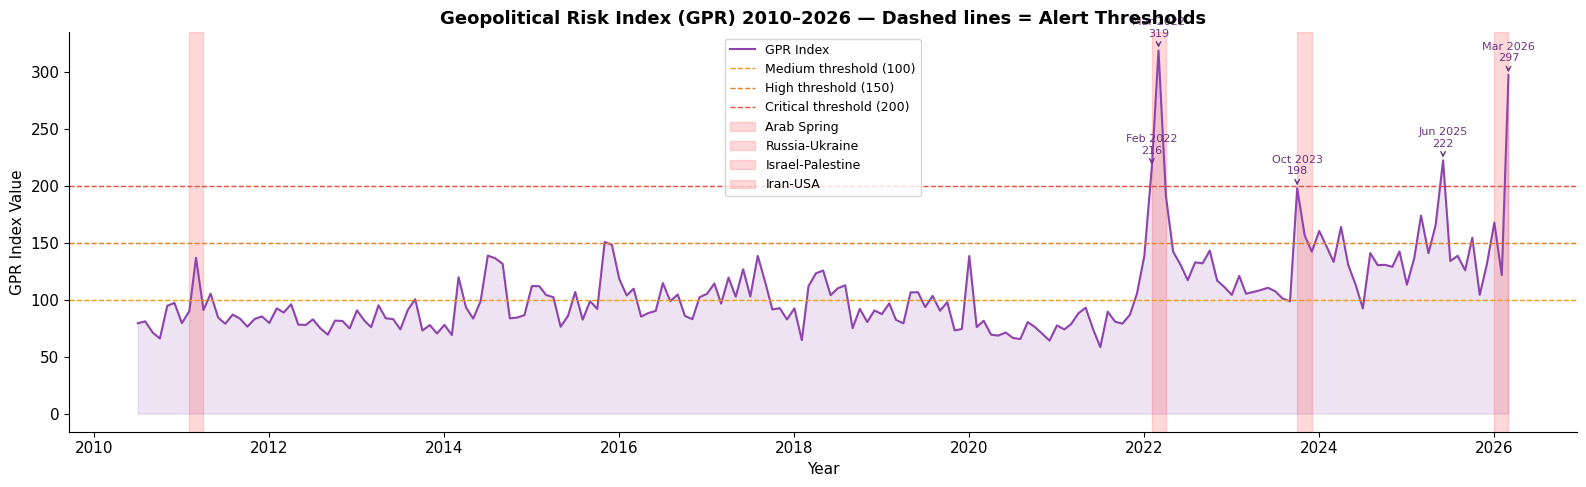

Saved: eda_03_gpr_trend.png


In [12]:

#! GPR index trend
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df['date'], df['GPR'], color='#8e44ad', linewidth=1.5, label='GPR Index')
ax.fill_between(df['date'], df['GPR'], alpha=0.15, color='#8e44ad')

# Risk level threshold lines
ax.axhline(y=100, color='#f39c12', linestyle='--', linewidth=1, label='Medium threshold (100)')
ax.axhline(y=150, color='#e67e22', linestyle='--', linewidth=1, label='High threshold (150)')
ax.axhline(y=200, color='#e74c3c', linestyle='--', linewidth=1, label='Critical threshold (200)')

# Annotate peaks
top5 = df.nlargest(5, 'GPR')
for _, row in top5.iterrows():
    ax.annotate(f"{row['date'].strftime('%b %Y')}\n{row['GPR']:.0f}",
                xy=(row['date'], row['GPR']),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=8, color='#6c3483',
                arrowprops=dict(arrowstyle='->', color='#6c3483', lw=1))

#! Shade conflict periods
conflict_periods = [
    ('2011-02-01', '2011-04-01', 'Arab Spring'),
    ('2022-02-01', '2022-04-01', 'Russia-Ukraine'),
    ('2023-10-01', '2023-12-01', 'Israel-Palestine'),
    ('2026-01-01', '2026-03-01', 'Iran-USA'),
]
for start, end, label in conflict_periods:
    ax.axvspan(pd.to_datetime(start), pd.to_datetime(end), alpha=0.15, color='red', label=label)

ax.set_title('Geopolitical Risk Index (GPR) 2010–2026 — Dashed lines = Alert Thresholds')
ax.set_ylabel('GPR Index Value')
ax.set_xlabel('Year')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('eda_03_gpr_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_03_gpr_trend.png')

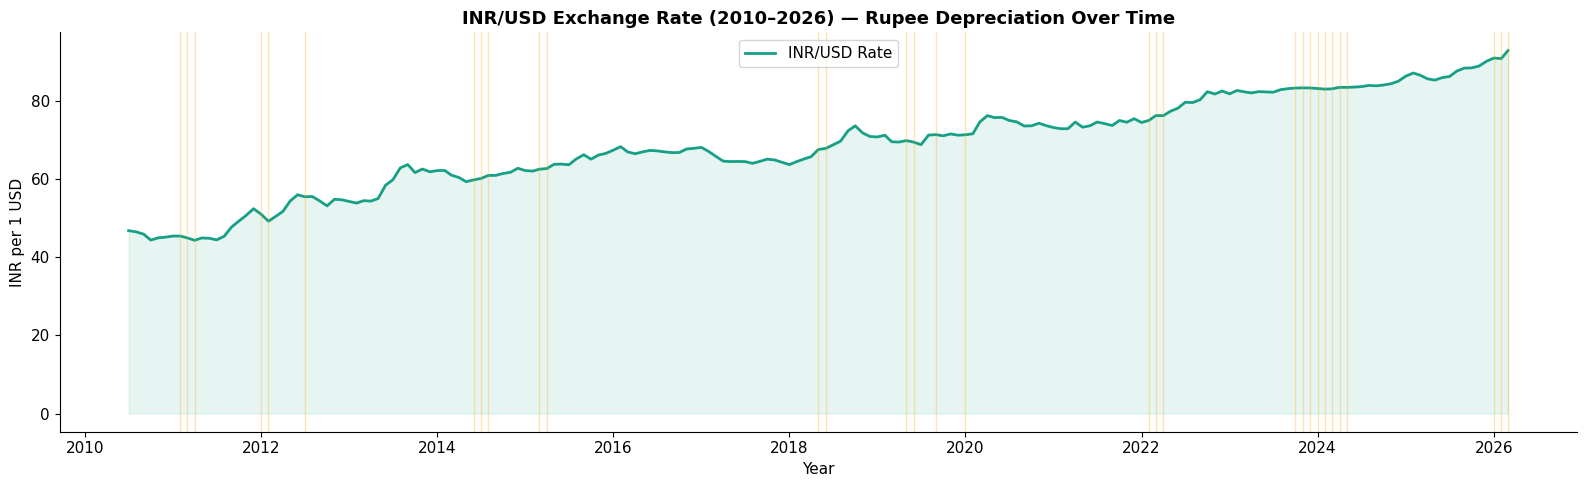

Saved: eda_04_inr_trend.png


In [13]:

#~ ─── 3d. INR/USD exchange rate trend
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df['date'], df['usd_rate'], color='#16a085', linewidth=2, label='INR/USD Rate')
ax.fill_between(df['date'], df['usd_rate'], alpha=0.1, color='#16a085')

for d in conflict_months:
    ax.axvline(x=d, color='orange', alpha=0.3, linewidth=1)

ax.set_title('INR/USD Exchange Rate (2010–2026) — Rupee Depreciation Over Time')
ax.set_ylabel('INR per 1 USD')
ax.set_xlabel('Year')
ax.legend()
plt.tight_layout()
plt.savefig('eda_04_inr_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_04_inr_trend.png')

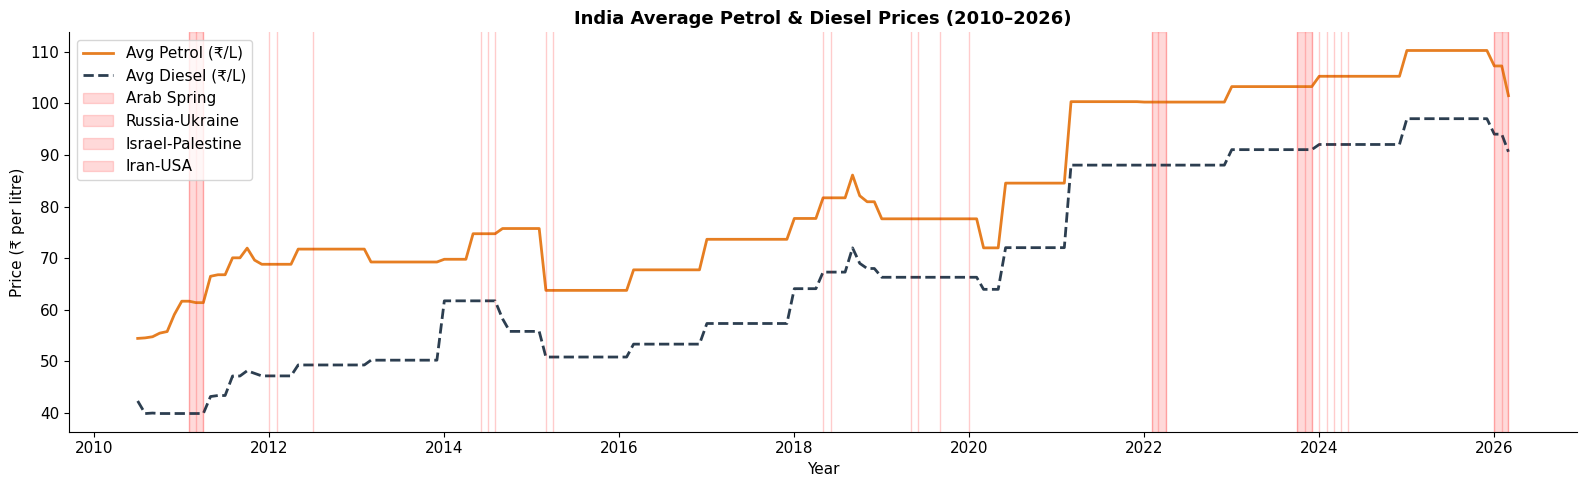

Saved: eda_05_fuel_trend.png


In [14]:

#* ─── 3e. Petrol & Diesel Trend
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df['date'], df['avg_petrol'], color='#e67e22', linewidth=2, label='Avg Petrol (₹/L)')
ax.plot(df['date'], df['avg_diesel'], color='#2c3e50', linewidth=2, label='Avg Diesel (₹/L)', linestyle='--')

for d in conflict_months:
    ax.axvline(x=d, color='red', alpha=0.2, linewidth=1)

#! Shade conflict periods
conflict_periods = [
    ('2011-02-01', '2011-04-01', 'Arab Spring'),
    ('2022-02-01', '2022-04-01', 'Russia-Ukraine'),
    ('2023-10-01', '2023-12-01', 'Israel-Palestine'),
    ('2026-01-01', '2026-03-01', 'Iran-USA'),
]
for start, end, label in conflict_periods:
    ax.axvspan(pd.to_datetime(start), pd.to_datetime(end), alpha=0.15, color='red', label=label)

ax.set_title('India Average Petrol & Diesel Prices (2010–2026)')
ax.set_ylabel('Price (₹ per litre)')
ax.set_xlabel('Year')
ax.legend()
plt.tight_layout()
plt.savefig('eda_05_fuel_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_05_fuel_trend.png')

# 4. Conflict impact analysis

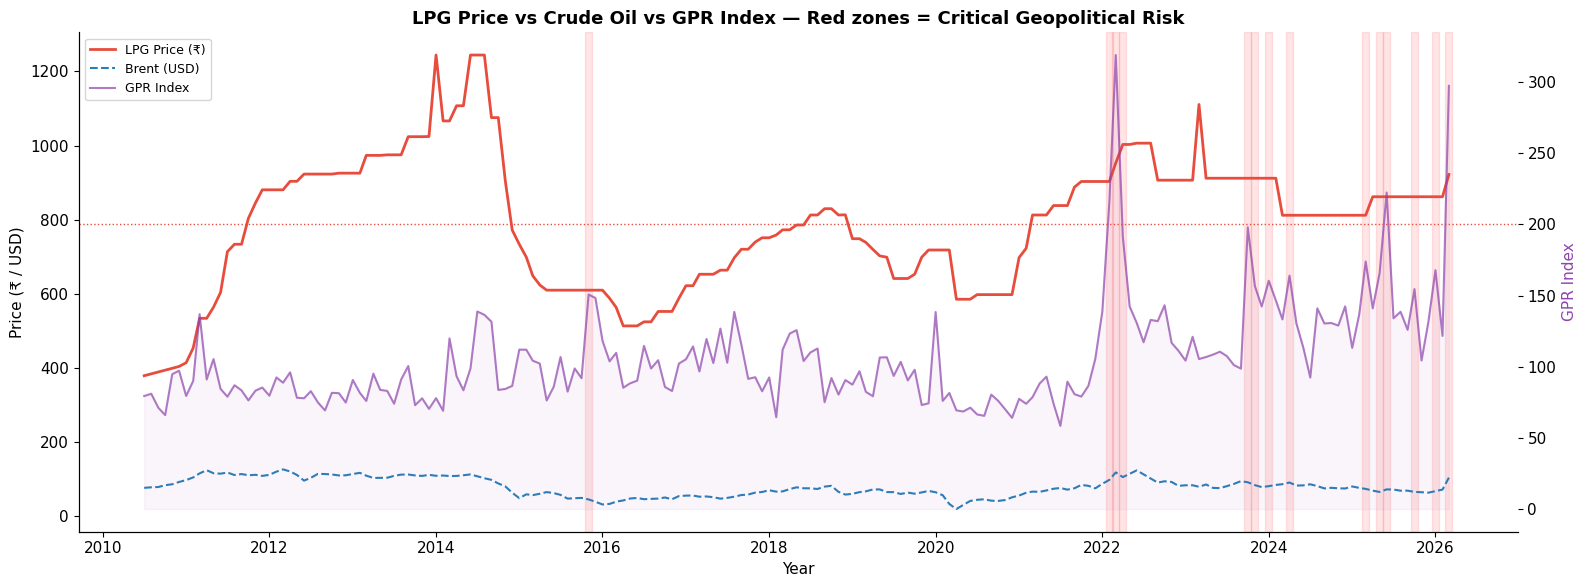

Saved: eda_06_combined_signals.png


In [15]:

#^ ─── 4a. All 4 SIGNALS On One Chart
fig, ax1 = plt.subplots(figsize=(16, 6))
ax2 = ax1.twinx()

# Left axis — prices
ax1.plot(df['date'], df['avg_lpg_price'],     color='#e74c3c', linewidth=2,   label='LPG Price (₹)')
ax1.plot(df['date'], df['brent_price'], color='#2980b9', linewidth=1.5, label='Brent (USD)', linestyle='--')

# Right axis — GPR
ax2.plot(df['date'], df['GPR'], color='#8e44ad', linewidth=1.5, label='GPR Index', alpha=0.7)
ax2.fill_between(df['date'], df['GPR'], alpha=0.05, color='#8e44ad')
ax2.axhline(y=200, color='#e74c3c', linestyle=':', linewidth=1)

# Shade critical conflict periods
critical = df[df['risk_level'] >= 2]
for _, row in critical.iterrows():
    ax1.axvspan(row['date'] - pd.Timedelta(days=15),
                row['date'] + pd.Timedelta(days=15),
                alpha=0.1, color='red')

ax1.set_ylabel('Price (₹ / USD)', color='black')
ax2.set_ylabel('GPR Index', color='#8e44ad')
ax1.set_xlabel('Year')
ax1.set_title('LPG Price vs Crude Oil vs GPR Index — Red zones = Critical Geopolitical Risk')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('eda_06_combined_signals.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_06_combined_signals.png')

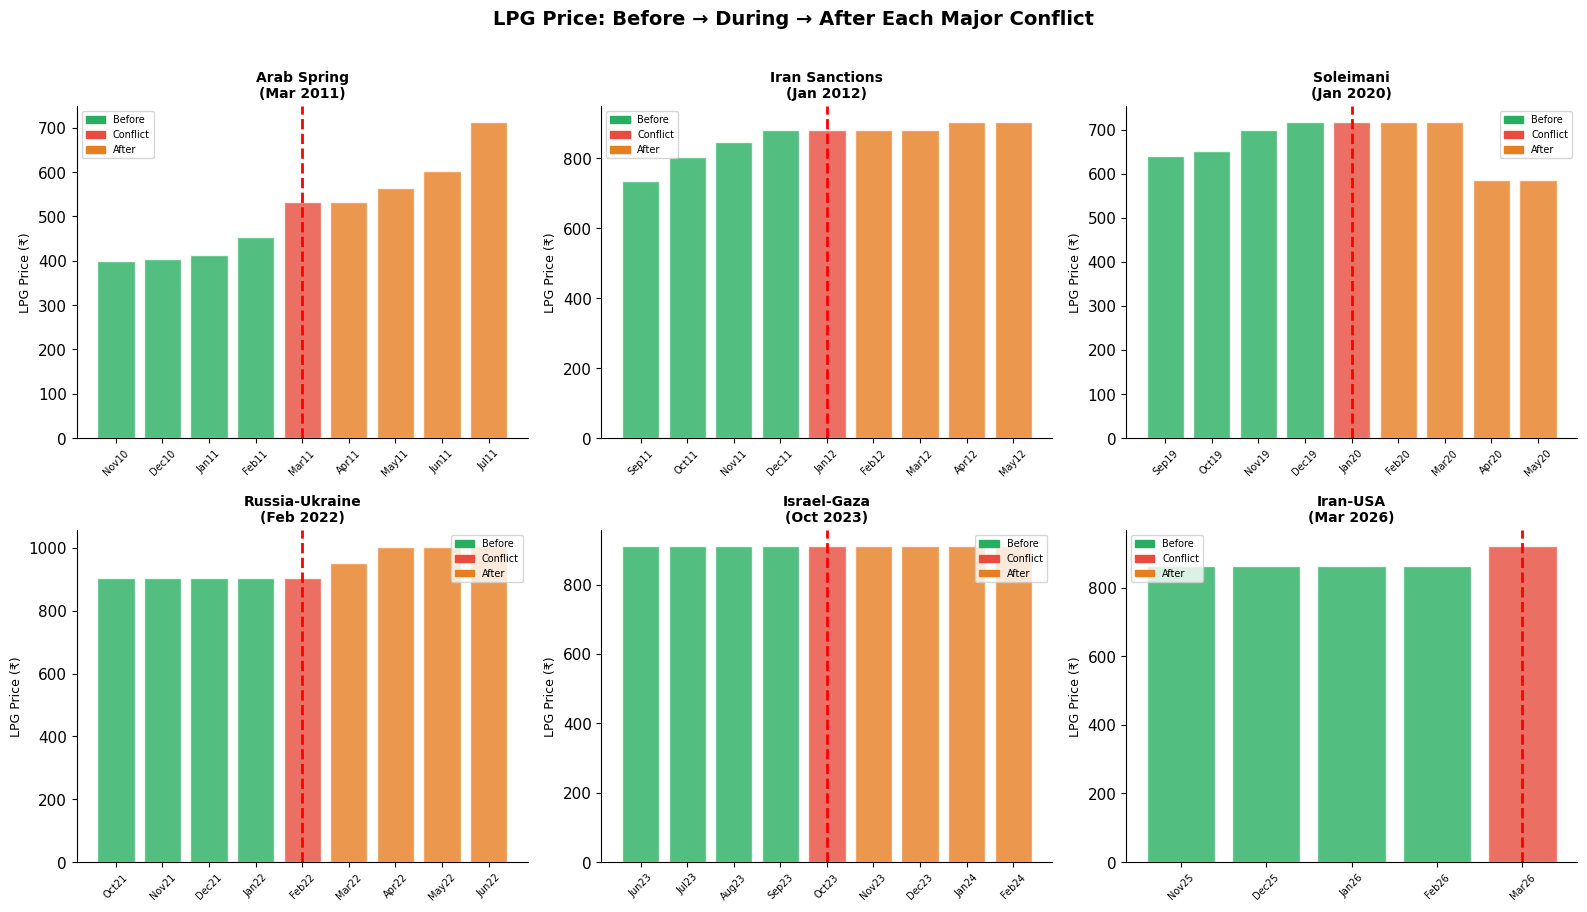

Saved: eda_07_conflict_impact.png


In [16]:

#? ─── 4b. Before vs During vs After
# For each conflict event, compare LPG price 3 months before, during, 3 months after

key_conflicts = {
    'Arab Spring\n(Mar 2011)':      '2011-03-01',
    'Iran Sanctions\n(Jan 2012)':   '2012-01-01',
    'Soleimani\n(Jan 2020)':        '2020-01-01',
    'Russia-Ukraine\n(Feb 2022)':   '2022-02-01',
    'Israel-Gaza\n(Oct 2023)':      '2023-10-01',
    'Iran-USA\n(Mar 2026)':         '2026-03-01',
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for idx, (event_name, date_str) in enumerate(key_conflicts.items()):
    event_date = pd.to_datetime(date_str)
    window = df[(df['date'] >= event_date - pd.DateOffset(months=4)) &
                (df['date'] <= event_date + pd.DateOffset(months=4))].copy()

    if len(window) == 0:
        continue

    ax = axes[idx]
    colors = ['#27ae60' if d < event_date else ('#e74c3c' if d == event_date else '#e67e22')
              for d in window['date']]

    ax.bar(range(len(window)), window['avg_lpg_price'], color=colors, alpha=0.8, edgecolor='white')
    ax.axvline(x=window['date'].tolist().index(event_date) if event_date in window['date'].tolist()
               else len(window)//2,
               color='red', linestyle='--', linewidth=2, label='Conflict')

    ax.set_title(event_name, fontsize=10)
    ax.set_ylabel('LPG Price (₹)', fontsize=9)
    ax.set_xticks(range(len(window)))
    ax.set_xticklabels([d.strftime('%b%y') for d in window['date']], rotation=45, fontsize=7)

    green_patch  = mpatches.Patch(color='#27ae60', label='Before')
    red_patch    = mpatches.Patch(color='#e74c3c', label='Conflict')
    orange_patch = mpatches.Patch(color='#e67e22', label='After')
    ax.legend(handles=[green_patch, red_patch, orange_patch], fontsize=7)

plt.suptitle('LPG Price: Before → During → After Each Major Conflict', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_07_conflict_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_07_conflict_impact.png')

=== CONFLICT vs NON-CONFLICT COMPARISON ===
Metric                     Normal     Conflict   Difference
----------------------------------------------------------
Avg LPG Price (₹)           778.2        839.9        +61.7
Avg Petrol (₹)               81.5         86.2         +4.7
Avg Diesel (₹)               66.7         71.8         +5.1
Avg Brent (USD)              75.4         88.9        +13.5


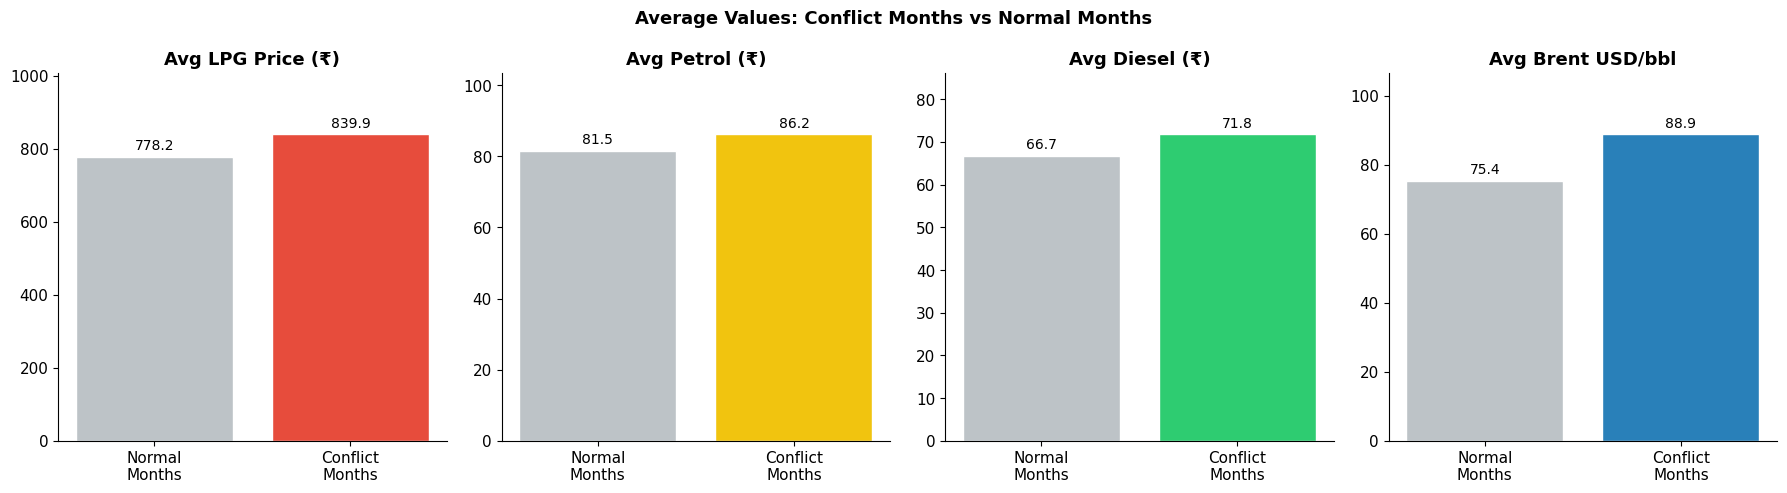

Saved: eda_08_conflict_vs_normal.png


In [27]:
#* 4c. Avg LPG Price — conflict vs non-conflict months

conflict_lpg     = df[df['conflict_event'] == 1]['avg_lpg_price'].mean()
non_conflict_lpg = df[df['conflict_event'] == 0]['avg_lpg_price'].mean()
conflict_petrol  = df[df['conflict_event'] == 1]['avg_petrol'].mean()
non_conflict_petrol = df[df['conflict_event'] == 0]['avg_petrol'].mean()
conflict_diesel  = df[df['conflict_event'] == 1]['avg_diesel'].mean()
non_conflict_diesel = df[df['conflict_event'] == 0]['avg_diesel'].mean()
conflict_brent   = df[df['conflict_event'] == 1]['brent_price'].mean()
non_conflict_brent = df[df['conflict_event'] == 0]['brent_price'].mean()

print('=== CONFLICT vs NON-CONFLICT COMPARISON ===')
print(f"{'Metric':<20} {'Normal':>12} {'Conflict':>12} {'Difference':>12}")
print('-'*58)
print(f"{'Avg LPG Price (₹)':<20} {non_conflict_lpg:>12.1f} {conflict_lpg:>12.1f} {conflict_lpg-non_conflict_lpg:>+12.1f}")
print(f"{'Avg Petrol (₹)':<20} {non_conflict_petrol:>12.1f} {conflict_petrol:>12.1f} {conflict_petrol-non_conflict_petrol:>+12.1f}")
print(f"{'Avg Diesel (₹)':<20} {non_conflict_diesel:>12.1f} {conflict_diesel:>12.1f} {conflict_diesel-non_conflict_diesel:>+12.1f}")
print(f"{'Avg Brent (USD)':<20} {non_conflict_brent:>12.1f} {conflict_brent:>12.1f} {conflict_brent-non_conflict_brent:>+12.1f}")

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
metrics = [
    ('Avg LPG Price (₹)', conflict_lpg, non_conflict_lpg, '#e74c3c'),
    ('Avg Petrol (₹)',    conflict_petrol, non_conflict_petrol, '#f1c40f'),
    ('Avg Diesel (₹)',    conflict_diesel, non_conflict_diesel, '#2ecc71'),
    ('Avg Brent USD/bbl', conflict_brent, non_conflict_brent, '#2980b9'),
]
for ax, (title, c_val, n_val, color) in zip(axes, metrics):
    # Width increased to 0.8 to reduce the gap
    bars = ax.bar(['Normal\nMonths', 'Conflict\nMonths'], [n_val, c_val],
                  color=['#bdc3c7', color], edgecolor='white', width=0.8)
    ax.bar_label(bars, fmt='%.1f', padding=3, fontsize=10)
    ax.set_title(title)
    ax.set_ylim(0, max(c_val, n_val) * 1.2)

plt.suptitle('Average Values: Conflict Months vs Normal Months', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_08_conflict_vs_normal.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_08_conflict_vs_normal.png')


# 5. Correlation Analysis

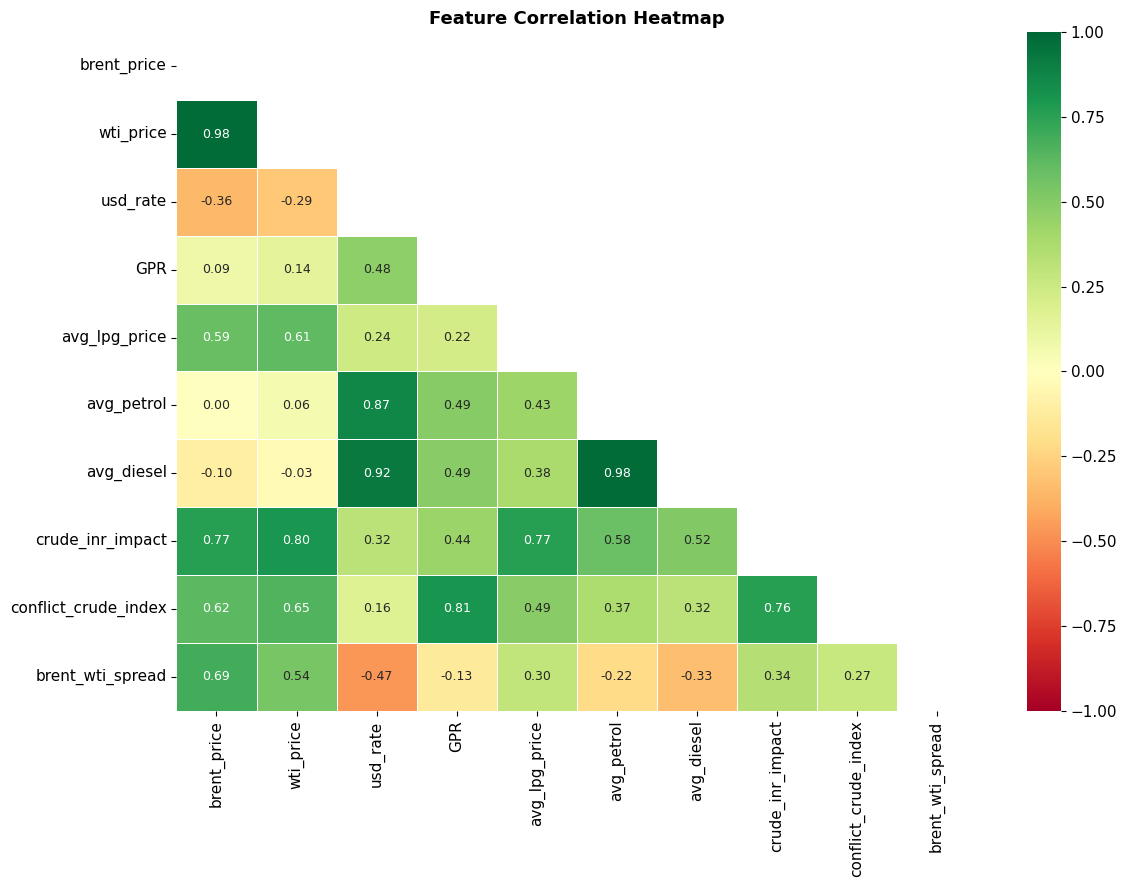

Saved: eda_09_correlation_heatmap.png


In [18]:

#todo 5a. Correlation Analysis Heatmap
corr_cols = ['brent_price','wti_price','usd_rate','GPR',
             'avg_lpg_price','avg_petrol','avg_diesel',
             'crude_inr_impact','conflict_crude_index','brent_wti_spread']

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('eda_09_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_09_correlation_heatmap.png')

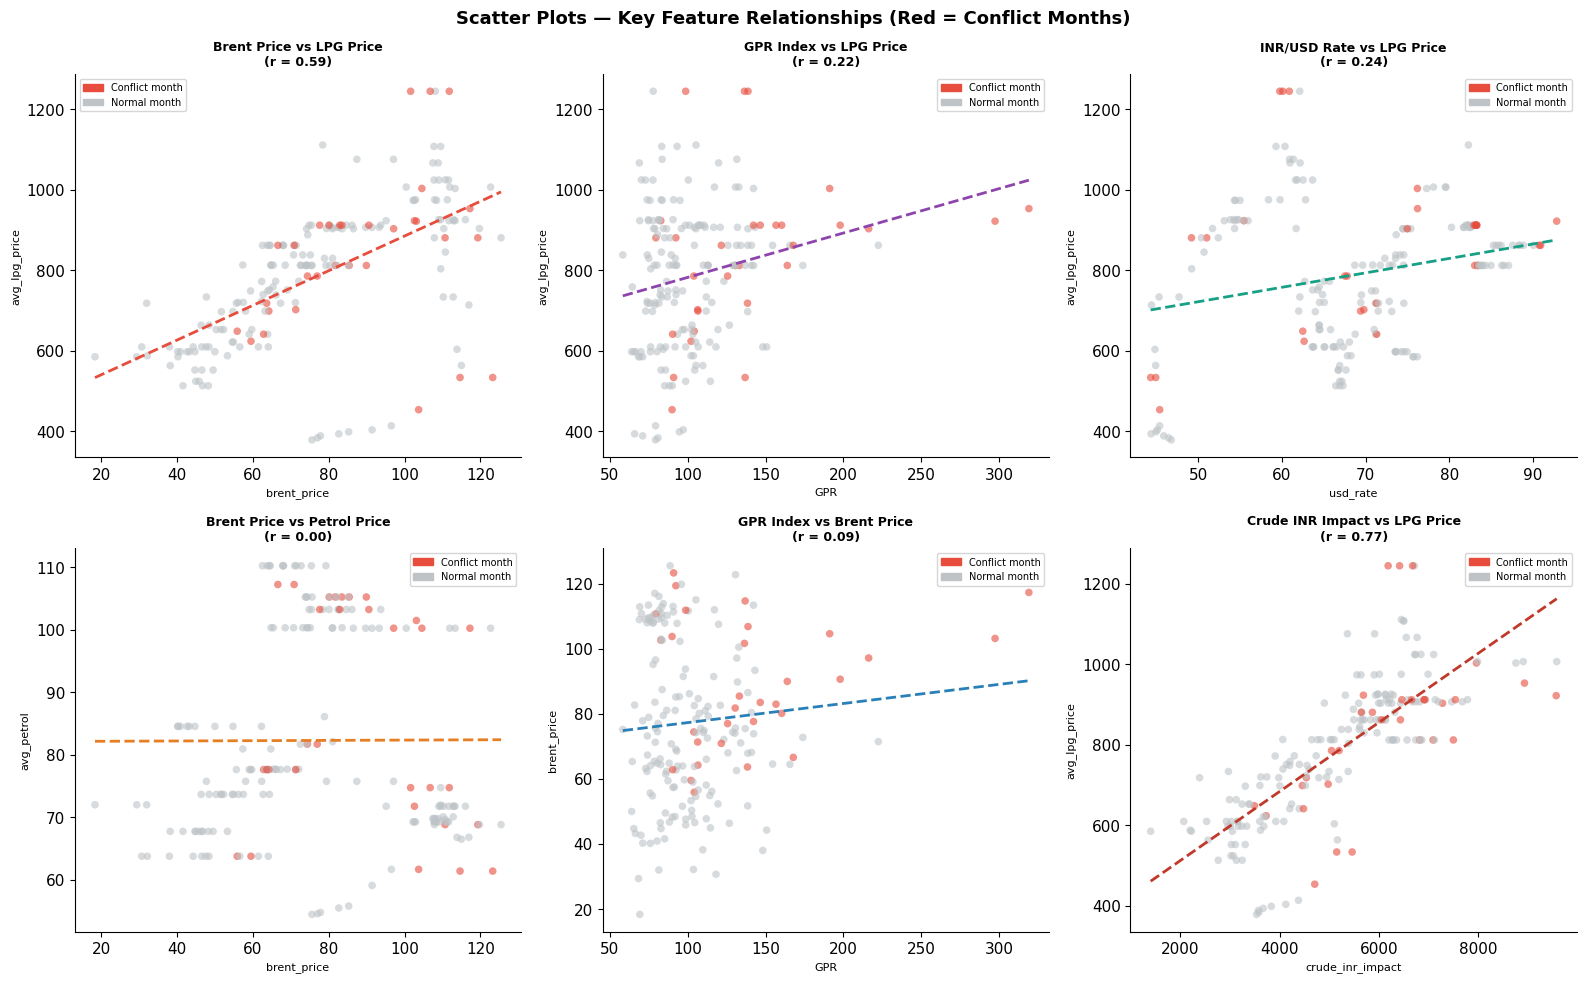

Saved: eda_10_scatter_plots.png


In [19]:

#? 5b. SCATTER PLOTS — Key realtionships
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

scatter_pairs = [
    ('brent_price', 'avg_lpg_price',    'Brent Price vs LPG Price',        '#e74c3c'),
    ('GPR',         'avg_lpg_price',    'GPR Index vs LPG Price',           '#8e44ad'),
    ('usd_rate',        'avg_lpg_price',    'INR/USD Rate vs LPG Price',        '#16a085'),
    ('brent_price', 'avg_petrol', 'Brent Price vs Petrol Price',      '#e67e22'),
    ('GPR',         'brent_price','GPR Index vs Brent Price',         '#2980b9'),
    ('crude_inr_impact','avg_lpg_price','Crude INR Impact vs LPG Price',    '#c0392b'),
]

for ax, (x, y, title, color) in zip(axes.flatten(), scatter_pairs):
    #^ Color by conflict event
    colors = df['conflict_event'].map({0: '#bdc3c7', 1: '#e74c3c'})
    ax.scatter(df[x], df[y], c=colors, alpha=0.6, s=30, edgecolors='none')

    #& Trend line
    z = np.polyfit(df[x].dropna(), df[y].dropna(), 1)
    p = np.poly1d(z)
    xline = np.linspace(df[x].min(), df[x].max(), 100)
    ax.plot(xline, p(xline), color=color, linewidth=2, linestyle='--')

    corr = df[[x, y]].corr().iloc[0, 1]
    ax.set_title(f'{title}\n(r = {corr:.2f})', fontsize=9)
    ax.set_xlabel(x, fontsize=8)
    ax.set_ylabel(y, fontsize=8)

    red_dot   = mpatches.Patch(color='#e74c3c', label='Conflict month')
    grey_dot  = mpatches.Patch(color='#bdc3c7', label='Normal month')
    ax.legend(handles=[red_dot, grey_dot], fontsize=7)

plt.suptitle('Scatter Plots — Key Feature Relationships (Red = Conflict Months)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_10_scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_10_scatter_plots.png')

# 6. Lag & Dealy pattern analysis

Best lag for GPR --> LPG:   0 months (corr=0.223)
Best lag for Brent --> LPG: 4 months (corr=0.671)


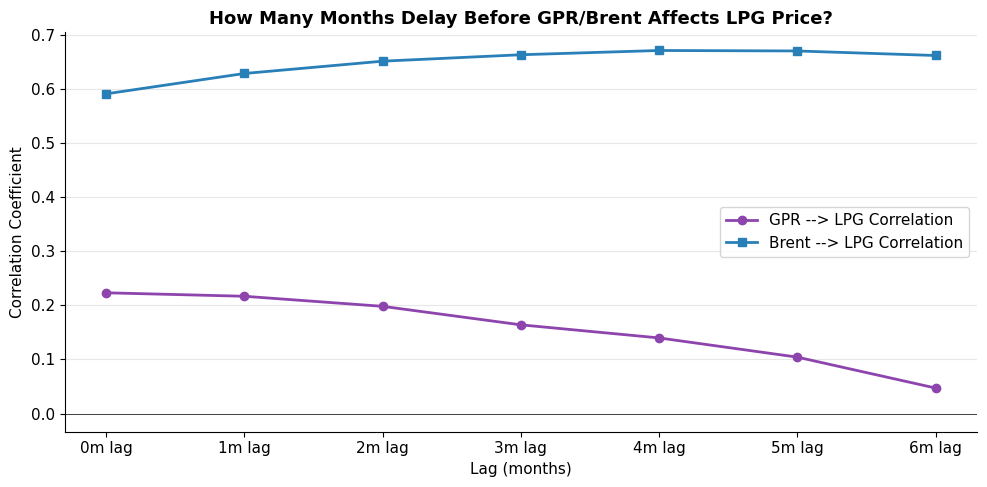

Saved: eda_11_lag_correlation.png


In [20]:

#* 6a. Lag correlation — GPR → LPG delay

lags = range(0, 7)
lag_corr_gpr_lpg   = [df['GPR'].shift(lag).corr(df['avg_lpg_price']) for lag in lags]
lag_corr_brent_lpg = [df['brent_price'].shift(lag).corr(df['avg_lpg_price']) for lag in lags]

fig, ax = plt.subplots(figsize=(10, 5))
x = list(lags)
ax.plot(x, lag_corr_gpr_lpg,   marker='o', color='#8e44ad', linewidth=2, label='GPR --> LPG Correlation')
ax.plot(x, lag_corr_brent_lpg, marker='s', color='#2980b9', linewidth=2, label='Brent --> LPG Correlation')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_xlabel('Lag (months)')
ax.set_ylabel('Correlation Coefficient')
ax.set_title('How Many Months Delay Before GPR/Brent Affects LPG Price?')
ax.set_xticks(x)
ax.set_xticklabels([f'{l}m lag' for l in x])
ax.legend()
ax.grid(axis='y', alpha=0.3)

best_gpr_lag   = lag_corr_gpr_lpg.index(max(lag_corr_gpr_lpg))
best_brent_lag = lag_corr_brent_lpg.index(max(lag_corr_brent_lpg))
print(f'Best lag for GPR --> LPG:   {best_gpr_lag} months (corr={max(lag_corr_gpr_lpg):.3f})')
print(f'Best lag for Brent --> LPG: {best_brent_lag} months (corr={max(lag_corr_brent_lpg):.3f})')

plt.tight_layout()
plt.savefig('eda_11_lag_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_11_lag_correlation.png')

# 7. Risk level distribution

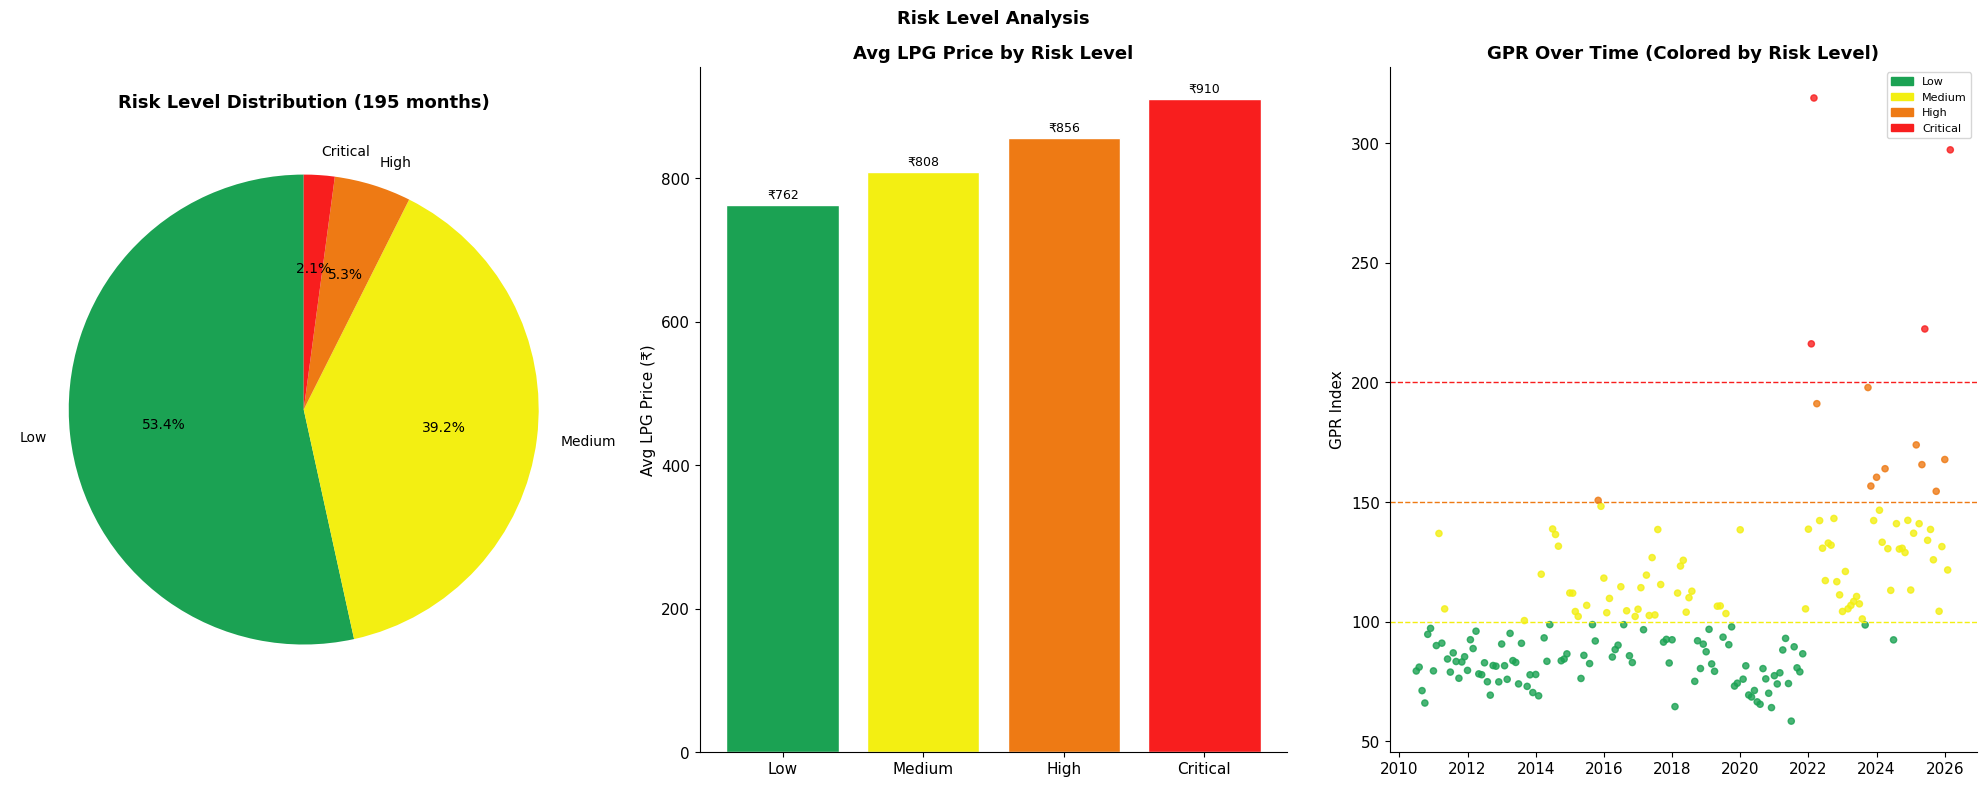

Saved: eda_12_risk_distribution.png


In [21]:

#? 7a. Risk Level Distribution (LPG price during different risk levels)

risk_map    = {0:'Low', 1:'Medium', 2:'High', 3:'Critical'}
risk_colors = {0:"#1ba253", 1:"#f3ef12", 2:"#ee7a14", 3:"#f81e1e"}
df['risk_label'] = df['risk_level'].map(risk_map)

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

# Pie chart
counts = df['risk_label'].value_counts()
pie_colors = [risk_colors[k] for k in [0,1,2,3] if risk_map[k] in counts.index]
axes[0].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=pie_colors, startangle=90, textprops={'fontsize': 10})
axes[0].set_title('Risk Level Distribution (195 months)')

# Bar chart with avg LPG per risk level
risk_lpg = df.groupby('risk_label')['avg_lpg_price'].mean().reindex(['Low','Medium','High','Critical'])
bars = axes[1].bar(risk_lpg.index, risk_lpg.values,
                   color=[risk_colors[0], risk_colors[1], risk_colors[2], risk_colors[3]],
                   edgecolor='white')
axes[1].bar_label(bars, fmt='₹%.0f', padding=3, fontsize=9)
axes[1].set_title('Avg LPG Price by Risk Level')
axes[1].set_ylabel('Avg LPG Price (₹)')

# Risk level over time
risk_colors_list = df['risk_level'].map(risk_colors)
axes[2].scatter(df['date'], df['GPR'], c=risk_colors_list, s=20, alpha=0.8)
axes[2].axhline(y=100, color='#f3ef12', linestyle='--', linewidth=1)
axes[2].axhline(y=150, color='#ee7a14', linestyle='--', linewidth=1)
axes[2].axhline(y=200, color='#f81e1e', linestyle='--', linewidth=1)
axes[2].set_title('GPR Over Time (Colored by Risk Level)')
axes[2].set_ylabel('GPR Index')

patches = [mpatches.Patch(color=risk_colors[k], label=risk_map[k]) for k in range(4)]
axes[2].legend(handles=patches, fontsize=8)

plt.suptitle('Risk Level Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_12_risk_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_12_risk_distribution.png')

# 8. India Import Dependency (Middle East)

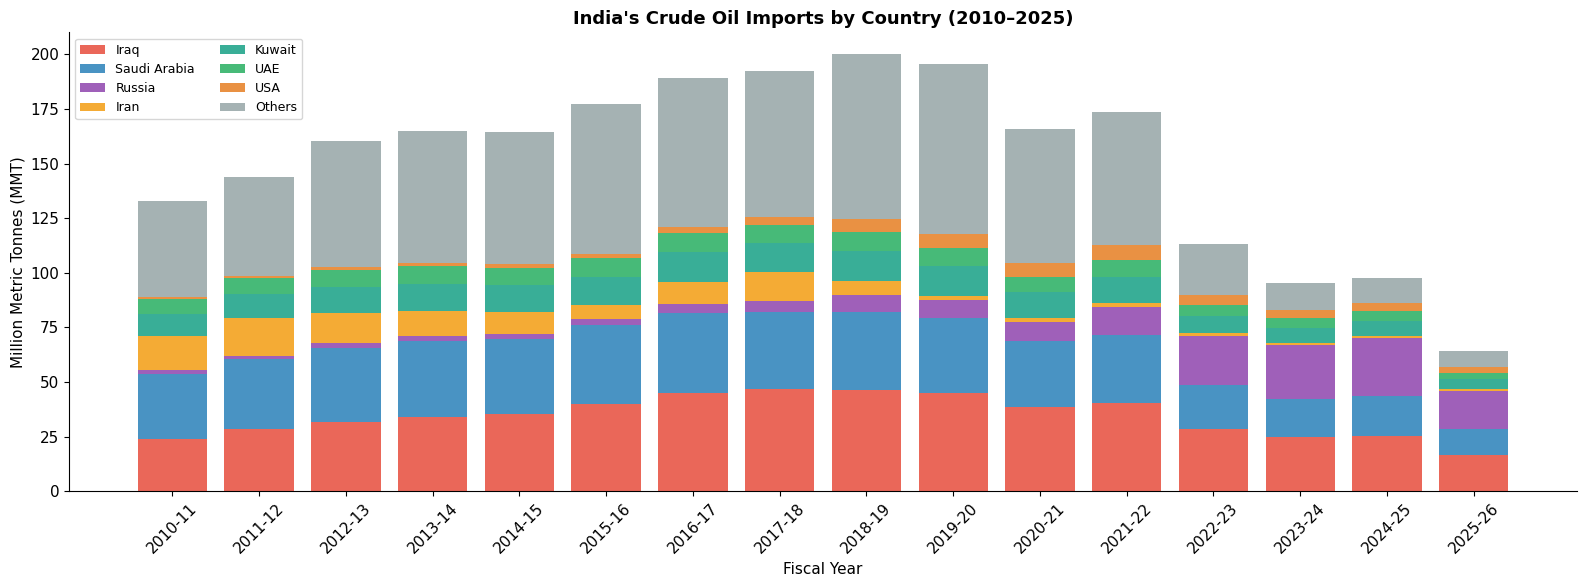

Saved: eda_13_import_dependency.png


In [ ]:

#& 8a. STACKED BAR — COUNTRY-WISE IMPORTS
country_cols = ['iraq_mmt','saudi_arabia_mmt','russia_mmt',
                'iran_mmt','kuwait_mmt','uae_mmt','usa_mmt','others_mmt']
country_labels = ['Iraq','Saudi Arabia','Russia','Iran','Kuwait','UAE','USA','Others']
country_colors = ['#e74c3c','#2980b9','#8e44ad','#f39c12','#16a085','#27ae60','#e67e22','#95a5a6']

fig, ax = plt.subplots(figsize=(16, 6))
bottom = np.zeros(len(imports))
for col, label, color in zip(country_cols, country_labels, country_colors):
    if col in imports.columns:
        vals = imports[col].values
        ax.bar(imports['year'], vals, bottom=bottom, label=label, color=color, alpha=0.85)
        bottom += vals

ax.set_title("India's Crude Oil Imports by Country (2010–2025)", fontsize=13, fontweight='bold')
ax.set_ylabel('Million Metric Tonnes (MMT)')
ax.set_xlabel('Fiscal Year')
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='upper left', fontsize=9, ncol=2)
plt.tight_layout()
plt.savefig('eda_13_import_dependency.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_13_import_dependency.png')

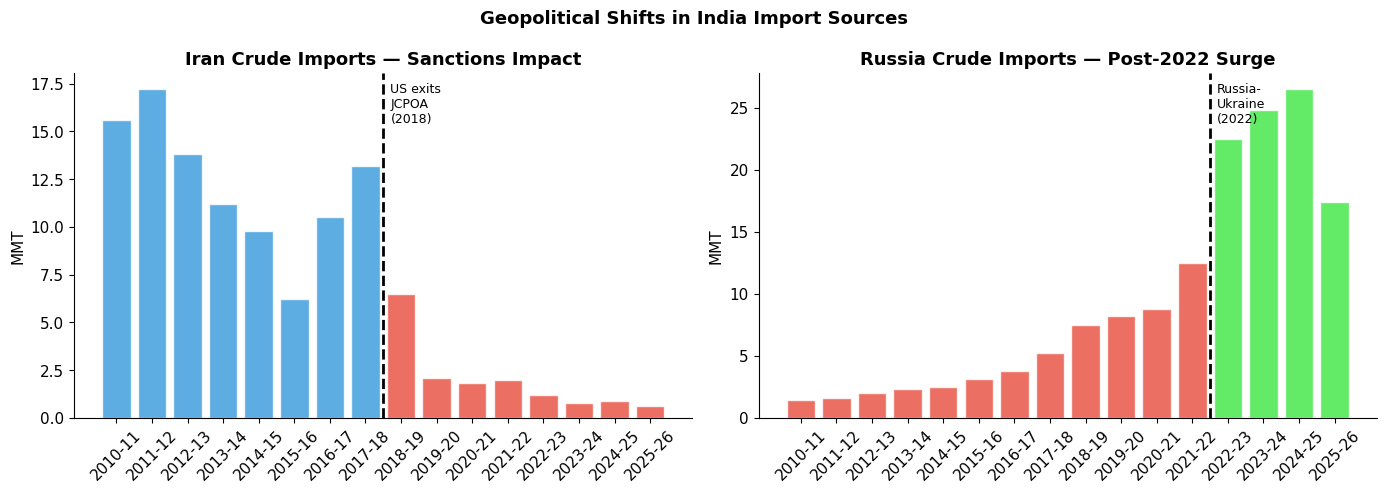

Saved: eda_14_iran_russia_imports.png


In [30]:

#* 8b. IRAN IMPORTS — BEFORE vs AFTER SANCTIONS
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Iran imports over years
if 'iran_mmt' in imports.columns:
    axes[0].bar(imports['year'], imports['iran_mmt'],
                color=['#e74c3c' if y >= '2018-19' else '#3498db' for y in imports['year']],
                alpha=0.8, edgecolor='white')
    axes[0].axvline(x=7.5, color='black', linestyle='--', linewidth=2)
    axes[0].text(7.7, imports['iran_mmt'].max() * 0.9, 'US exits\nJCPOA\n(2018)',
                 fontsize=9, color='black')
    axes[0].set_title('Iran Crude Imports — Sanctions Impact')
    axes[0].set_ylabel('MMT')
    axes[0].tick_params(axis='x', rotation=45)

# Russia imports — rise after 2022
if 'russia_mmt' in imports.columns:
    axes[1].bar(imports['year'], imports['russia_mmt'],
                color=["#3ce742" if y >= '2022-23' else '#e74c3c' for y in imports['year']],
                alpha=0.8, edgecolor='white')
    axes[1].axvline(x=11.5, color='black', linestyle='--', linewidth=2)
    axes[1].text(11.7, imports['russia_mmt'].max() * 0.9, 'Russia-\nUkraine\n(2022)',
                 fontsize=9, color='black')
    axes[1].set_title('Russia Crude Imports — Post-2022 Surge')
    axes[1].set_ylabel('MMT')
    axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Geopolitical Shifts in India Import Sources', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_14_iran_russia_imports.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_14_iran_russia_imports.png')

# 9. Key fndings & summary

In [ ]:

#todo 9. PRINT ALL KEY FINDINGS
print('='*60)
print('         EDA KEY FINDINGS SUMMARY')
print('='*60)

print('\n PRICE GROWTH (2010 → 2026):')
print(f"  LPG:    ₹{df['avg_lpg_price'].iloc[0]:.0f} → ₹{df['avg_lpg_price'].iloc[-1]:.0f}  (+{((df['avg_lpg_price'].iloc[-1]/df['avg_lpg_price'].iloc[0])-1)*100:.0f}%)")
print(f"  Petrol: ₹{df['avg_petrol'].iloc[0]:.0f} → ₹{df['avg_petrol'].iloc[-1]:.0f}  (+{((df['avg_petrol'].iloc[-1]/df['avg_petrol'].iloc[0])-1)*100:.0f}%)")
print(f"  INR:    {df['usd_rate'].iloc[0]:.1f} → {df['usd_rate'].iloc[-1]:.1f}  (Rupee depreciated {((df['usd_rate'].iloc[-1]/df['usd_rate'].iloc[0])-1)*100:.0f}%)")

print('\n CONFLICT IMPACT:')
print(f"  Avg LPG during conflict: ₹{df[df['conflict_event']==1]['avg_lpg_price'].mean():.0f}")
print(f"  Avg LPG during normal:   ₹{df[df['conflict_event']==0]['avg_lpg_price'].mean():.0f}")
diff = df[df['conflict_event']==1]['avg_lpg_price'].mean() - df[df['conflict_event']==0]['avg_lpg_price'].mean()
print(f"  Difference: ₹{diff:.0f} higher during conflicts")

print('\n CORRELATIONS WITH LPG PRICE:')
for col in ['brent_price','wti_price','usd_rate','GPR','crude_inr_impact']:
    corr = df[col].corr(df['avg_lpg_price'])
    print(f"  {col:<25}: {corr:+.3f}")

print('\n  TOP 5 HIGHEST RISK MONTHS:')
top5 = df.nlargest(5, 'GPR')[['date','GPR','brent_price','avg_lpg_price','risk_label']]
print(top5.to_string(index=False))

print('\n EDA COMPLETE — 14 charts saved.')
print('   Next step: ML Algorithms')

         EDA KEY FINDINGS SUMMARY

📈 PRICE GROWTH (2010 → 2026):
  LPG:    ₹378 → ₹922  (+144%)
  Petrol: ₹54 → ₹102  (+86%)
  INR:    46.8 → 92.8  (Rupee depreciated 99%)

🔥 CONFLICT IMPACT:
  Avg LPG during conflict: ₹840
  Avg LPG during normal:   ₹778
  Difference: ₹62 higher during conflicts

📊 CORRELATIONS WITH LPG PRICE:
  brent_price              : +0.591
  wti_price                : +0.610
  usd_rate                 : +0.244
  GPR                      : +0.223
  crude_inr_impact         : +0.766

⚠️  TOP 5 HIGHEST RISK MONTHS:
      date    GPR  brent_price  avg_lpg_price risk_label
2022-03-01 318.95       117.25          952.9   Critical
2026-03-01 297.27       103.13          921.7   Critical
2025-06-01 222.38        71.44          861.7   Critical
2022-02-01 216.16        97.13          902.9   Critical
2023-10-01 197.89        90.60          911.7       High

✅ EDA COMPLETE — 14 charts saved.
   Next step: ML Algorithms
